# Ciência de Dados e Inteligência Artificial
## Previsão da qualidade de vinhos por Machine Learning

>**Por** Cid Frota Saldanha Filho

**Dataset:** Wine Quality — UCI Machine Learning Repository\
**Modelos avaliados:** KNN e Random Forest

---


# 1. Objetivo do trabalho

O objetivo deste trabalho é explorar o conjunto de dados **Wine Quality**, identificar relações entre as características físico-químicas dos vinhos e sua avaliação de qualidade e verificar se essas características permitem construir um modelo capaz de classificar a qualidade do vinho.

## Pergunta 1

> **É possível prever, a partir das características físico-químicas, se um vinho possui qualidade igual ou superior a 7?**

## Pergunta 2

> **O envelhecimento do vinho é popularmente conhecido como determinante de qualidade. Essa ideia pode ser comprovada pela análise dos dados propostos?**

## Hipóteses exploradas

**1 — Teor alcoólico:** vinhos com maior teor alcoólico tendem a receber maiores notas.

**2 — Acidez volátil:** vinhos com maior acidez volátil tendem a apresentar menores notas de qualidade.

**3 — Dióxido de enxofre livre:** vinhos com valores menores (principal taxa variada com a idade do vinho) tendem a ser melhor avaliados.

As hipóteses serão investigadas por análise exploratória.


# 2. Bibliotecas utilizadas

Serão utilizadas bibliotecas apresentadas ao longo das aulas e necessárias para as diferentes etapas do trabalho.

- **Pandas:** organização e análise dos dados em tabelas.
- **Matplotlib:** construção dos gráficos da análise exploratória.
- **Scikit-learn:** preparação dos dados, criação dos modelos e avaliação dos resultados.
- **Joblib:** salvamento do melhor modelo em formato `.joblib`.


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import joblib

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


# 3. Carregamento do conjunto de dados
O dataset contém características físico-químicas de vinhos e uma avaliação de qualidade atribuída a cada amostra. Neste trabalho, utilizarei a base de **vinhos brancos**, por conter um volume maior de dados dentro do repositório que a opção de vinhos vermelhos.

A variável `quality` representa a nota de qualidade e será utilizada posteriormente para criar a variável alvo que os modelos deverão prever.


In [95]:
# @title
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df = pd.read_csv(url, sep=";")

print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

display(df.head())


Quantidade de linhas: 4898
Quantidade de colunas: 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# 4. Análise exploratória dos dados

A análise exploratória busca compreender o comportamento das variáveis antes da construção dos modelos.

A exploração será direcionada às duas hipóteses do início: a relação entre **teor alcoólico e qualidade** e entre **acidez volátil e qualidade**.

Observa-se uma maior concentração de vinhos na classe de qualidade inferior a 7. Essa característica deve ser considerada na interpretação dos resultados dos modelos.


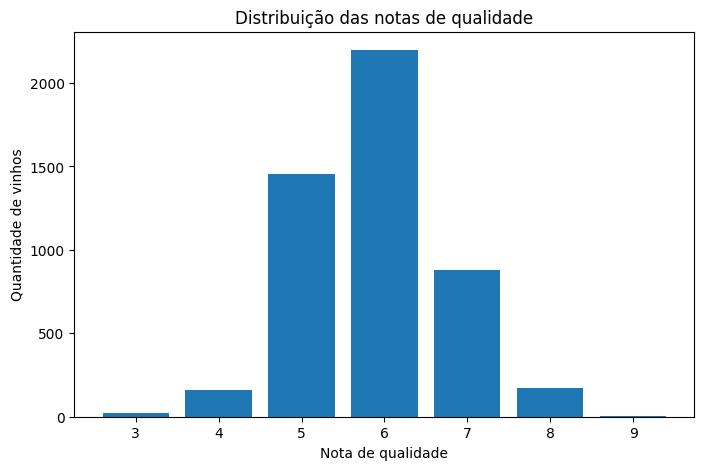

In [96]:
# @title
quality_counts = df["quality"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.title("Distribuição das notas de qualidade")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de vinhos")
plt.show()


## 4.1 Hipótese 1 — Teor alcoólico

Para investigar a primeira hipótese, foi calculado o teor alcoólico médio para cada nota de qualidade.

Observa-se uma tendência geral de aumento do teor alcoólico nas notas mais altas. A média passa de aproximadamente 10% nas notas mais baixas para mais de 12% na nota 9. Apesar de existir uma pequena redução conforme a melhora entre as notas 3, 4 e 5, a partir da nota 5 o crescimento se torna bastante evidente.

Dessa forma, os resultados observados apoiam a hipótese de que vinhos com maior teor alcoólico tendem a receber maiores notas de qualidade.

Essa relação representa uma associação observada nos dados e não permite afirmar causalidade.

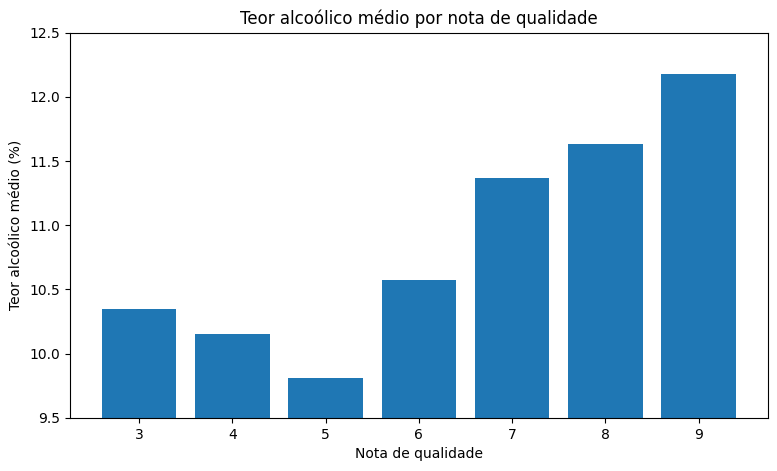

In [97]:
# @title
alcohol_mean = (
    df.groupby("quality")["alcohol"]
    .mean()
)

plt.figure(figsize=(9, 5))
plt.bar(alcohol_mean.index.astype(str), alcohol_mean.values)

plt.title("Teor alcoólico médio por nota de qualidade")
plt.xlabel("Nota de qualidade")
plt.ylabel("Teor alcoólico médio (%)")

plt.ylim(9.5, 12.5)

plt.show()

## 4.2 Hipótese 2 — Acidez volátil

Para investigar a segunda hipótese, foi calculada a acidez volátil média para cada nota de qualidade.

Os resultados não apresentam uma tendência linear clara. A acidez volátil média é mais elevada nas notas 3 e 4, diminui nas notas 5, 6 e 7 e volta a apresentar um pequeno aumento nas notas 8 e 9.

Portanto, os dados apresentam alguma evidência de associação entre maior acidez volátil e menores notas nas categorias de menor qualidade, mas o comportamento observado não é suficientemente regular para confirmar uma tendência de redução da acidez conforme a qualidade aumenta.
Dessa forma, a hipótese 2 não é claramente confirmada pela análise exploratória.

Essa relação representa uma associação observada nos dados e não permite afirmar causalidade.


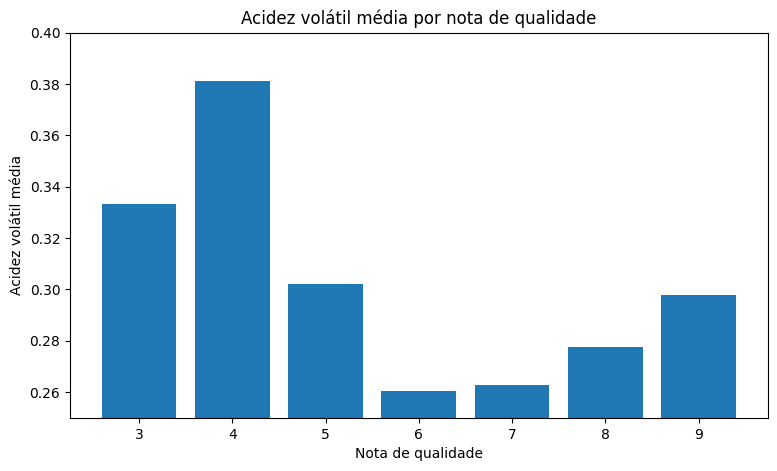

In [98]:
# @title
volatile_acidity_mean = (
    df.groupby("quality")["volatile acidity"]
    .mean()
)

plt.figure(figsize=(9, 5))
plt.bar(
    volatile_acidity_mean.index.astype(str),
    volatile_acidity_mean.values
)

plt.title("Acidez volátil média por nota de qualidade")
plt.xlabel("Nota de qualidade")
plt.ylabel("Acidez volátil média")

plt.ylim(0.25, 0.40)

plt.show()


## 4.3 Hipótese 3 —  Dióxido de enxofre livre
Para investigar a terceira hipótese, foi calculado o valor médio de dióxido de enxofre livre para cada nota de qualidade.

Os resultados não apresentam uma tendência linear de redução dos valores conforme a qualidade aumenta. A média é bastante elevada na nota 3, cai na nota 4 e volta a aumentar na nota 5. A partir daí, os valores permanecem próximos entre as notas 6, 7, 8 e 9, com pequenas variações.

Dessa forma, a hipótese 3 não é confirmada pela análise exploratória, pois os dados não apresentam um comportamento que indique que menores valores de dióxido de enxofre livre `(vinhos envelhecidos)` estejam associados a maiores notas de qualidade.

Essa relação representa uma associação observada nos dados e não permite afirmar causalidade.

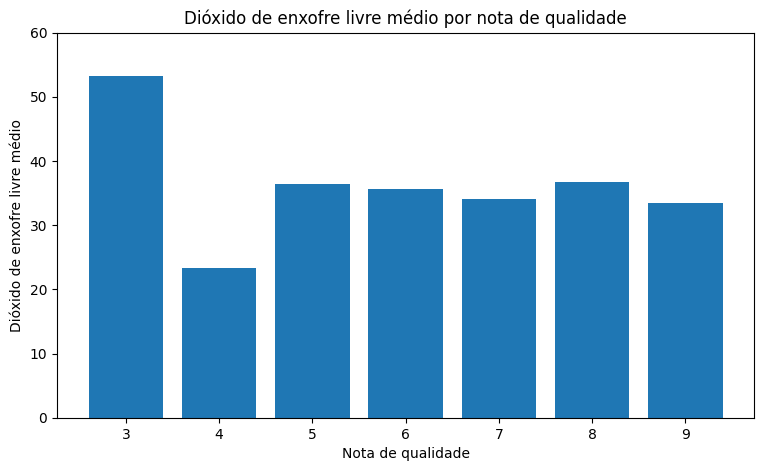

In [99]:
# @title
free_sulfur_dioxide_mean = (
    df.groupby("quality")["free sulfur dioxide"]
    .mean()
)

plt.figure(figsize=(9, 5))
plt.bar(
    free_sulfur_dioxide_mean.index.astype(str),
    free_sulfur_dioxide_mean.values
)

plt.title("Dióxido de enxofre livre médio por nota de qualidade")
plt.xlabel("Nota de qualidade")
plt.ylabel("Dióxido de enxofre livre médio")

plt.ylim(0, 60)

plt.show()


## 4.4 Matriz de correlação
A matriz de correlação complementa os gráficos anteriores e permite observar a intensidade e as relações entre as variáveis.

Entre as características analisadas, o teor alcoólico apresenta a correlação positiva mais evidente com a qualidade, enquanto a acidez volátil apresenta uma correlação negativa, porém fraca. Esse resultado é compatível com as tendências observadas nos gráficos anteriores, especialmente no caso do teor alcoólico.

Já o dióxido de enxofre livre apresenta uma correlação muito próxima de zero com a qualidade, indicando uma relação linear praticamente inexistente. Esse resultado é compatível com o comportamento observado no gráfico e, portanto, não confirma a hipótese 3 de que menores valores de dióxido de enxofre livre tendem a estar associados a maiores notas.

Além disso, como o conjunto de dados não possui uma variável que registre a idade do vinho, a análise dessas características não permite comprovar diretamente que o envelhecimento seja determinante para a qualidade. O dióxido de enxofre livre pode ser analisado apenas como uma aproximação indireta da questão levantada.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.02,0.29,0.09,0.02,-0.05,0.09,0.27,-0.43,-0.02,-0.12,-0.11
volatile acidity,-0.02,1.00,-0.15,0.06,0.07,-0.10,0.09,0.03,-0.03,-0.04,0.07,-0.19
citric acid,0.29,-0.15,1.00,0.09,0.11,0.09,0.12,0.15,-0.16,0.06,-0.08,-0.01
residual sugar,0.09,0.06,0.09,1.00,0.09,0.30,0.40,0.84,-0.19,-0.03,-0.45,-0.10
chlorides,0.02,0.07,0.11,0.09,1.00,0.10,0.20,0.26,-0.09,0.02,-0.36,-0.21
free sulfur dioxide,-0.05,-0.10,0.09,0.30,0.10,1.00,0.62,0.29,-0.00,0.06,-0.25,0.01
total sulfur dioxide,0.09,0.09,0.12,0.40,0.20,0.62,1.00,0.53,0.00,0.13,-0.45,-0.17
density,0.27,0.03,0.15,0.84,0.26,0.29,0.53,1.00,-0.09,0.07,-0.78,-0.31
pH,-0.43,-0.03,-0.16,-0.19,-0.09,-0.00,0.00,-0.09,1.00,0.16,0.12,0.10
sulphates,-0.02,-0.04,0.06,-0.03,0.02,0.06,0.13,0.07,0.16,1.00,-0.02,0.05


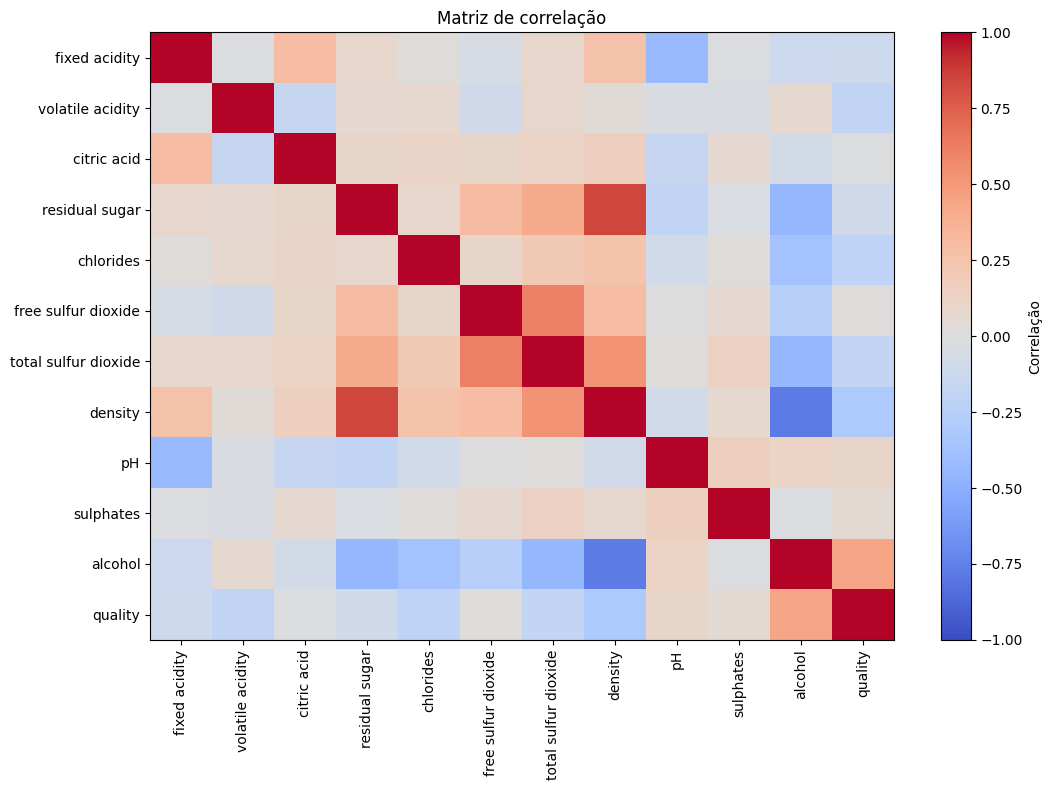

In [100]:
# @title
# 5.4 Correlação entre as variáveis

corr = df.corr(numeric_only=True)

display(corr.round(2))

plt.figure(figsize=(11, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlação")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()


# 5. Transformação da variável de qualidade

O conjunto de dados apresenta diferentes notas de qualidade para os vinhos. Para este trabalho, essa avaliação será transformada em duas categorias:

0 — qualidade menor que 7

1 — qualidade igual ou superior a 7

O valor "7" foi adotado como ponto de corte por decisão metodológica: durante a exploração, foram considerados os cortes 6, 7 e 8. Com o corte em 6, o KNN apresentou acurácia de aproximadamente 76%. Já o corte em 8 produziu uma classe positiva muito pequena e uma acurácia próxima de 96%, mas esse resultado se mostrou pouco representativo devido ao forte desbalanceamento entre as classes.

Assim, o corte em 7 apresentou uma divisão mais adequada para o problema. 3.838 observações (78,36%) ficaram abaixo de 7 e 1.060 (21,64%) ficaram em 7 ou acima.

A partir dessa transformação, o modelo também passa a responder a uma pergunta mais simples em uma interpretação mais natural da classificação:

> *Eu beberia ou não beberia?*

In [101]:
df["target"] = (df["quality"] >= 7).astype(int)

In [102]:
# @title
print("Valores por classe:")
display(
    df["target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Qualidade < 7",
        1: "Qualidade >= 7"
    })
    .to_frame("Quantidade")
)

print("Percentual de cada classe:")
display(
    (
        df["target"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .rename(index={
            0: "Qualidade < 7",
            1: "Qualidade >= 7"
        })
        .to_frame("Percentual (%)")
    )
)


Valores por classe:


,Quantidade
target,
Qualidade < 7,3838
Qualidade >= 7,1060


Percentual de cada classe:


,Percentual (%)
target,
Qualidade < 7,78.36
Qualidade >= 7,21.64


# 6. Separação entre treino e teste

Agora que a variável que queremos prever foi definida, precisamos separar os dados em dois grupos:

**80% para treinamento:** representa a maior parte dos dados e permite que os algoritmos tenham uma quantidade suficiente de exemplos para aprender os padrões presentes no conjunto

**20% para teste:** mantém uma parcela dos dados separada para avaliar o desempenho dos modelos em observações que não participarão do treinamento.

A proporção 80/20 foi escolhida por representar um equilíbrio entre a quantidade de dados disponível para o aprendizado e uma quantidade suficiente de observações para avaliar os modelos.

Além disso, é a proporção utilizada no exemplo trabalhado em aula.


In [103]:
# @title
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Dados de treinamento: {len(X_train)} observações")
print(f"Dados de teste: {len(X_test)} observações")


Dados de treinamento: 3918 observações
Dados de teste: 980 observações


Foi utilizado `random_state = 42` assim como usado em sala para que a divisão aleatória seja reproduzível. Dessa forma, ao executar novamente o notebook com os mesmos dados, obteremos a mesma divisão entre treinamento e teste.


# 7. Modelo 1 — K-Nearest Neighbors (KNN)

Foram avaliados diferentes valores de `k de 3 a 13` antes de definir `k=11` pela precisão encontrada para diferentes valores de `random_state`.

Além da quantidade de vizinhos, foi utilizado o parâmetro *`weights="distance"`*, que atribui maior influência aos vizinhos mais próximos na classificação.
Essa abordagem permite utilizar um número maior de vizinhos sem considerar todos eles com a mesma importância.

## Padronização dos dados

A escala das variáveis influencia diretamente o resultado da classificação, no entanto, no conjunto Wine Quality, as variáveis possuem escalas diferentes. Assim, para que todas possam contribuir de forma mais equilibrada para o cálculo das distâncias, os dados serão padronizados antes da aplicação do KNN.

A padronização é feita a partir dos dados de treinamento. Depois, essa mesma transformação é aplicada aos dados de teste, que permanecem separados durante o treinamento do modelo.

In [104]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [105]:
knn = KNeighborsClassifier(
    n_neighbors=11,
    weights="distance"
)

knn.fit(X_train_scaled, y_train)

knn_prediction = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_prediction)

print(f"Acurácia do KNN: {knn_accuracy:.2%}")

Acurácia do KNN: 88.37%


## Avaliação do KNN

O modelo apresentou acurácia de `88,37%` no conjunto de teste.

A matriz de confusão será utilizada como complemento para visualizar os acertos e erros realizados pelo modelo em cada classe.


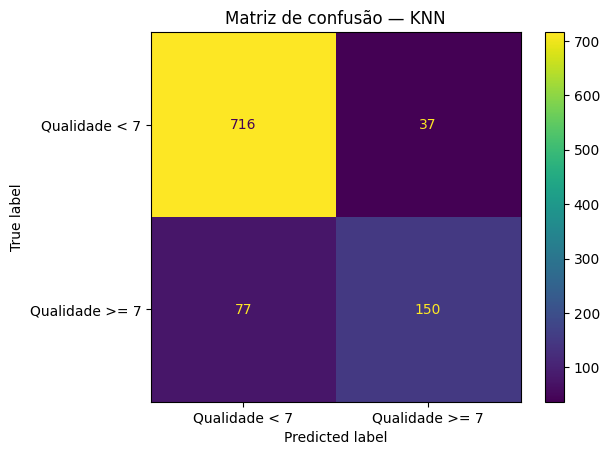

In [106]:
# @title
knn_cm = confusion_matrix(y_test, knn_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=["Qualidade < 7", "Qualidade >= 7"]
)

disp.plot()
plt.title("Matriz de confusão — KNN")
plt.show()


# 8. Modelo 2 — Random Forest

Neste modelo, não é necessário realizar a padronização utilizada no KNN, pois o Random Forest não depende de cálculos de distância entre as observações.

Será utilizado `n_estimators = 100`.


In [107]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print(f"Acurácia do Random Forest: {rf_accuracy:.2%}")


Acurácia do Random Forest: 88.88%


## Avaliação do Random Forest

Assim como no KNN, a acurácia será utilizada como principal métrica para verificar o desempenho do modelo.

A matriz de confusão permite complementar essa análise mostrando a quantidade de classificações corretas e incorretas em cada uma das duas categorias.


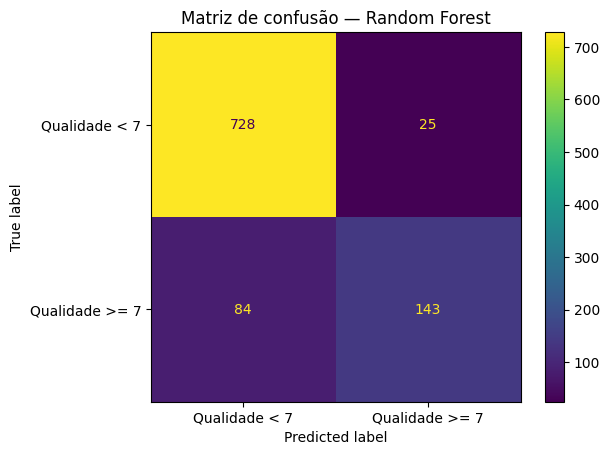

In [108]:
rf_cm = confusion_matrix(y_test, rf_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Qualidade < 7", "Qualidade >= 7"]
)

disp.plot()
plt.title("Matriz de confusão — Random Forest")
plt.show()


# 9. Comparação dos modelos

Agora podemos comparar diretamente o desempenho dos dois algoritmos.

Os dois modelos foram avaliados utilizando a mesma divisão entre treinamento e teste e a mesma variável-alvo, permitindo uma comparação direta dos resultados.

Além da acurácia, as matrizes de confusão apresentadas anteriormente permitem complementar a análise, mostrando como cada modelo distribuiu seus acertos e erros entre as duas classes.

In [109]:
# @title
comparacao = pd.DataFrame({
    "Modelo": ["KNN", "Random Forest"],
    "Acurácia": [knn_accuracy, rf_accuracy]
})

display(comparacao.style.format({"Acurácia": "{:.2%}"}))

melhor_modelo_nome = comparacao.loc[
    comparacao["Acurácia"].idxmax(), "Modelo"
]

melhor_modelo = knn if melhor_modelo_nome == "KNN" else rf
melhor_acuracia = comparacao["Acurácia"].max()

print(f"Melhor modelo: {melhor_modelo_nome}")


,Modelo,Acurácia
0,KNN,88.37%
1,Random Forest,88.88%


Melhor modelo: Random Forest


## Interpretação da comparação

O KNN apresentou acurácia de 88,37%, enquanto o Random Forest apresentou 88,88%.

Portanto, considerando exclusivamente a acurácia obtida no conjunto de teste, o Random Forest apresentou o melhor resultado, com uma diferença de aproximadamente 0,51 ponto percentual em relação ao KNN, indicando que ambos apresentaram desempenho semelhante neste experimento.

A matriz de confusão mostra que o Random Forest apresentou menos falsos positivos, enquanto o KNN identificou corretamente uma quantidade ligeiramente maior de vinhos pertencentes à classe de qualidade igual ou superior a 7. Assim, embora valores próximos, os dois modelos apresentam comportamentos diferentes na distribuição dos erros.

# 10. Conclusão

O trabalho investigou se características físico-químicas poderiam ser utilizadas para classificar vinhos de acordo com um ponto de corte de qualidade definido. Para isso, a variável de qualidade foi transformada em duas categorias:
> vinhos com qualidade `inferior a 7`.

> vinhos com qualidade `igual ou superior a 7`.

A análise exploratória permitiu investigar as três hipóteses propostas.
1. Foi observada uma associação entre o maior teor alcoólico e notas de qualidade mais elevadas.

2. Já a análise da acidez volátil não apresentou uma tendência linear suficientemente clara para confirmar a relação proposta.

3. Em relação ao dióxido de enxofre livre, também não foi observada uma tendência regular de redução dos valores conforme a qualidade aumenta.

Quanto à pergunta sobre o envelhecimento do vinho, os dados não permitem comprovar diretamente essa ideia, pois o conjunto utilizado não possui uma variável que registre a idade das amostras. No entanto, a análise do dióxido de enxofre livre permite apenas uma observação indireta e, neste caso, não apresentou evidências suficientes para sustentar a relação proposta entre menores valores dessa variável e maior qualidade, apontando para a invalidação da ideia.

Em seguida, os dados foram divididos em 80% para treinamento e 20% para teste para avaliar os algoritmos KNN e Random Forest.
O KNN alcançou 88,37%, enquanto o Random Forest apresentou 88,88%, sendo selecionado como o melhor modelo neste experimento.

A transformação da qualidade em duas categorias também permitiu uma interpretação mais palpável do problema:
>“eu beberia ou não beberia?”.

Nesse caso, a pergunta representa se o vinho pertence ou não à categoria de qualidade igual ou superior a 7 *(não é uma previsão real do comportamento de consumo).*

Por fim, os resultados indicam que as características físico-químicas utilizadas possuem capacidade de contribuir para a classificação da qualidade dos vinhos analisados. No entanto, os resultados representam associações e padrões encontrados neste conjunto de dados e não permitem afirmar que uma característica isolada seja responsável pela qualidade atribuída ao vinho.

# 11. Salvamento do melhor modelo

Depois de comparar os dois algoritmos, o modelo com maior acurácia é salvo automaticamente em formato `.joblib`.



In [110]:
joblib.dump(melhor_modelo, "melhor_modelo_wine_quality.joblib")

print(
    f"Modelo salvo com sucesso: melhor_modelo_wine_quality.joblib "
    f"({melhor_modelo_nome})"
)


Modelo salvo com sucesso: melhor_modelo_wine_quality.joblib (Random Forest)


# ***Referências***

CORTEZ, P.; CERDEIRA, A.; ALMEIDA, F.; MATOS, T.; REIS, J. *Modeling wine preferences by data mining from physicochemical properties*. Decision Support Systems, v. 47, n. 4, p. 547–553, 2009.

UCI MACHINE LEARNING REPOSITORY. *Wine Quality*. Disponível em: https://archive.ics.uci.edu/dataset/186/wine+quality.
